In [35]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
from sklearn.metrics import f1_score, confusion_matrix
from collections import defaultdict
from data import generate_examples, generate_examples_with_error_type, parenthesis, make_edit_labels
from model import DyckTransformer
import matplotlib.pyplot as plt

In [36]:
VOCAB = ["(", ")", "[", "]", "[PAD]", "[CLS]", "[SEP]"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}
itos = {i: tok for tok, i in stoi.items()}
edit_stoi = {"OK": 0, "DELETE": 1, "INSERT())": 2, "INSERT(])": 3, "REPLACE())": 4, "REPLACE(])": 5}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
model = DyckTransformer(
    vocab_size=len(VOCAB),
    pad_idx=stoi["[PAD]"],
    num_edit_labels=6,
    d_model=128,
    n_heads=4,
    n_layers=2,
    max_len=80,
    dropout=0.1
)
model.load_state_dict(torch.load("../results/models/det_dyck_transformer.pt", map_location=device))
model.to(device)
model.eval()

DyckTransformer(
  (embed): Embedding(7, 128)
  (pos): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (cls_head): Linear(in_features=128, out_features=2, bias=True)
  (token_head): Linear(in_features=128, out_features=6, bias=True)
)

In [38]:
det_test_data_typed = generate_examples_with_error_type(5000, task="detection")

In [39]:
batch_size = 64
results = defaultdict(lambda: {"preds": [], "labels": []})

model.eval()
with torch.no_grad():
    for i in range(0, len(det_test_data_typed), batch_size):
        batch = det_test_data_typed[i:i+batch_size]
        xs = [x for x, _, _ in batch]
        ys = [y for _, y, _ in batch]
        types = [t for _, _, t in batch]
        xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
        cls_logits, _ = model(xs)
        preds = torch.argmax(cls_logits, dim=1).cpu().tolist()
        for pred, label, etype in zip(preds, ys, types):
            results[etype]["preds"].append(pred)
            results[etype]["labels"].append(label)

In [40]:
all_preds = []
all_labels = []

for etype in ["none", "E1", "E2", "E3", "E4"]:
    preds = results[etype]["preds"]
    labels = results[etype]["labels"]
    acc = sum(p == l for p, l in zip(preds, labels)) / len(labels)
    print(f"{etype}: acc={acc:.4f} n={len(labels)}")
    all_preds.extend(preds)
    all_labels.extend(labels)

# overall metrics across everything
overall_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
overall_f1 = f1_score(all_labels, all_preds, average="macro")
cm = confusion_matrix(all_labels, all_preds)
print(f"\noverall: acc={overall_acc:.4f} f1={overall_f1:.4f}")
print(f"confusion matrix:\n{cm}")

none: acc=1.0000 n=2467
E1: acc=1.0000 n=647
E2: acc=1.0000 n=657
E3: acc=1.0000 n=597
E4: acc=1.0000 n=632

overall: acc=1.0000 f1=1.0000
confusion matrix:
[[2533    0]
 [   0 2467]]


In [41]:
print(f"{'':>6} {'pred correct':>14} {'pred corrupted':>16}")
for etype in ["none", "E1", "E2", "E3", "E4"]:
    preds = results[etype]["preds"]
    labels = results[etype]["labels"]
    pred_correct = preds.count(1)
    pred_corrupted = preds.count(0)
    print(f"{etype:>6} {pred_correct:>14} {pred_corrupted:>16}")

         pred correct   pred corrupted
  none           2467                0
    E1              0              647
    E2              0              657
    E3              0              597
    E4              0              632


In [42]:
ood_n5 = generate_examples_with_error_type(5000, min_len=40, max_len=80, max_depth=5, task="detection")
ood_n6 = generate_examples_with_error_type(5000, min_len=40, max_len=80, max_depth=6, task="detection")
ood_n7 = generate_examples_with_error_type(5000, min_len=40, max_len=80, max_depth=7, task="detection")

In [43]:
def evaluate(data, model, stoi, device, batch_size=64):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            xs = [x for x, _, _ in batch]
            ys = [y for _, y, _ in batch]
            xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
            cls_logits, _ = model(xs)
            preds = torch.argmax(cls_logits, dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(ys)
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    return acc

acc_n5 = evaluate(ood_n5, model, stoi, device)
acc_n6 = evaluate(ood_n6, model, stoi, device)
acc_n7 = evaluate(ood_n7, model, stoi, device)

print(f"n=5: {acc_n5:.4f}")
print(f"n=6: {acc_n6:.4f}")
print(f"n=7: {acc_n7:.4f}")

n=5: 0.7296
n=6: 0.6476
n=7: 0.5796


C:\Users\sarav\AppData\Local\Temp\ipykernel_9704\3803023212.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


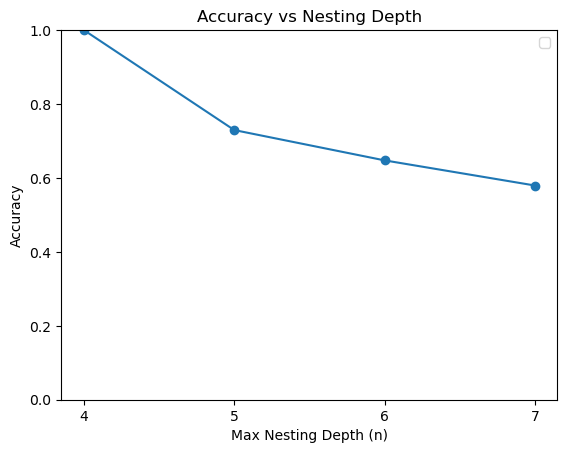

In [44]:
acc_n4 = evaluate(det_test_data_typed, model, stoi, device)

depths = [4, 5, 6, 7]
accs = [acc_n4, acc_n5, acc_n6, acc_n7]

plt.plot(depths, accs, marker="o")
plt.title("Accuracy vs Nesting Depth")
plt.xlabel("Max Nesting Depth (n)")
plt.ylabel("Accuracy")
plt.xticks(depths)
plt.ylim(0, 1)
plt.legend()
plt.savefig("../results//figures/det_ood_acc_vs_depth.pdf")
plt.show()

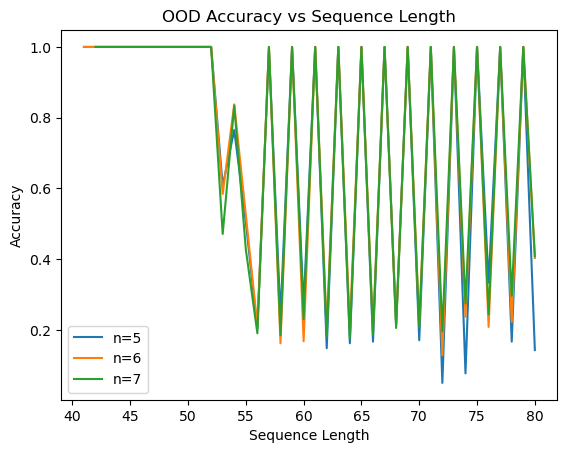

In [45]:
def evaluate_by_length(data, model, stoi, device, batch_size=64):
    model.eval()
    length_results = defaultdict(lambda: {"preds": [], "labels": []})
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            xs = [x for x, _, _ in batch]
            ys = [y for _, y, _ in batch]
            # actual length = number of non-PAD tokens
            lengths = [sum(1 for tok in x if tok != "[PAD]") for x in xs]
            xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
            cls_logits, _ = model(xs)
            preds = torch.argmax(cls_logits, dim=1).cpu().tolist()
            for pred, label, length in zip(preds, ys, lengths):
                length_results[length]["preds"].append(pred)
                length_results[length]["labels"].append(label)

    sorted_lengths = sorted(length_results.keys())
    accs = [sum(p == l for p, l in zip(length_results[ln]["preds"], length_results[ln]["labels"])) / len(length_results[ln]["labels"]) for ln in sorted_lengths]
    return sorted_lengths, accs

lengths_n5, accs_n5 = evaluate_by_length(ood_n5, model, stoi, device)
lengths_n6, accs_n6 = evaluate_by_length(ood_n6, model, stoi, device)
lengths_n7, accs_n7 = evaluate_by_length(ood_n7, model, stoi, device)

plt.plot(lengths_n5, accs_n5, label="n=5")
plt.plot(lengths_n6, accs_n6, label="n=6")
plt.plot(lengths_n7, accs_n7, label="n=7")
plt.title("OOD Accuracy vs Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("../results/figures/det_ood_acc_vs_length.pdf")
plt.show()

In [46]:
even_correct = [(ln, acc) for ln, acc in zip(lengths_n7, accs_n7) if ln % 2 == 0]
odd_correct = [(ln, acc) for ln, acc in zip(lengths_n7, accs_n7) if ln % 2 != 0]

print("even lengths avg acc:", sum(a for _, a in even_correct) / len(even_correct))
print("odd lengths avg acc:", sum(a for _, a in odd_correct) / len(odd_correct))

even lengths avg acc: 0.49079040261965645
odd lengths avg acc: 0.9388223774156597


In [47]:
for label, dataset in [("n=5", ood_n5), ("n=6", ood_n6), ("n=7", ood_n7)]:
    results_ood = defaultdict(lambda: {"preds": [], "labels": []})
    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch = dataset[i:i+batch_size]
            xs = [x for x, _, _ in batch]
            ys = [y for _, y, _ in batch]
            types = [etype for _, _, etype in batch]
            xs = torch.tensor([[stoi[tok] for tok in x] for x in xs]).to(device)
            cls_logits, _ = model(xs)
            preds = torch.argmax(cls_logits, dim=1).cpu().tolist()
            for pred, lab, etype in zip(preds, ys, types):
                results_ood[etype]["preds"].append(pred)
                results_ood[etype]["labels"].append(lab)

    print(f"\n{label}")
    print(f"{'':>6} {'pred clean':>12} {'pred corrupted':>16}")
    for etype in ["none", "E1", "E2", "E3", "E4"]:
        preds = results_ood[etype]["preds"]
        labs = results_ood[etype]["labels"]
        pred_clean = preds.count(1)
        pred_corrupted = preds.count(0)
        acc = sum(p == l for p, l in zip(preds, labs)) / len(labs)
        print(f"{etype:>6} {pred_clean:>12} {pred_corrupted:>16}   acc={acc:.4f}")


n=5
         pred clean   pred corrupted
  none         1329             1145   acc=0.5372
    E1           93              557   acc=0.8569
    E2          114              506   acc=0.8161
    E3            0              627   acc=1.0000
    E4            0              629   acc=1.0000

n=6
         pred clean   pred corrupted
  none          972             1575   acc=0.3816
    E1          101              555   acc=0.8460
    E2           86              478   acc=0.8475
    E3            0              614   acc=1.0000
    E4            0              619   acc=1.0000

n=7
         pred clean   pred corrupted
  none          629             1909   acc=0.2478
    E1          103              556   acc=0.8437
    E2           90              559   acc=0.8613
    E3            0              635   acc=1.0000
    E4            0              519   acc=1.0000


In [48]:
def pushdown_automaton(tokens):

    stack = []
    pairs = {")" : "(", "]": "["}
    
    for tok in tokens:
        if tok in ["(", "["]:
            stack.append(tok)
        elif tok in [")", "]"]:
            if not stack or stack[-1] != pairs[tok]:
                return 0
            stack.pop()
        elif tok in ["[CLS]", "[SEP]", "[PAD]"]:
            continue  # ignore special tokens
    
    return 1 if len(stack) == 0 else 0

In [49]:
# in-distribution
pda_preds = [pushdown_automaton(tokens) for tokens, _, _ in det_test_data_typed]
pda_labels = [y for _, y, _ in det_test_data_typed]
pda_acc = sum(p == l for p, l in zip(pda_preds, pda_labels)) / len(pda_labels)
print(f"PDA in-distribution acc: {pda_acc:.4f}")

# OOD
pda_preds_ood = [pushdown_automaton(tokens) for tokens, _, _ in ood_n7]
pda_labels_ood = [y for _, y, _ in ood_n7]
pda_acc_ood = sum(p == l for p, l in zip(pda_preds_ood, pda_labels_ood)) / len(pda_labels_ood)
print(f"PDA OOD (n=7) acc: {pda_acc_ood:.4f}")

PDA in-distribution acc: 1.0000
PDA OOD (n=7) acc: 1.0000
